In [1]:
%pip install plotly pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import plotly.express as px
import pandas as pd

In [5]:
df = pd.read_csv("filehehe.csv",encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


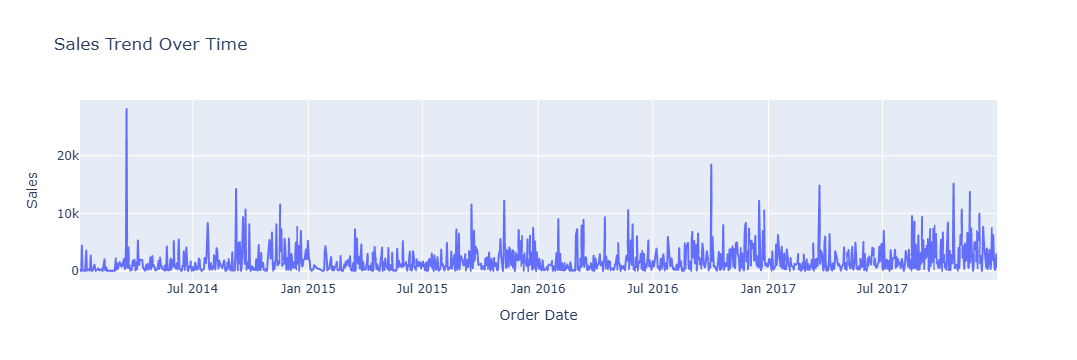

In [6]:
sales_trend = df.groupby('Order Date')['Sales'].sum().reset_index()
fig = px.line(sales_trend, x='Order Date', y='Sales', title = 'Sales Trend Over Time')
fig.show()

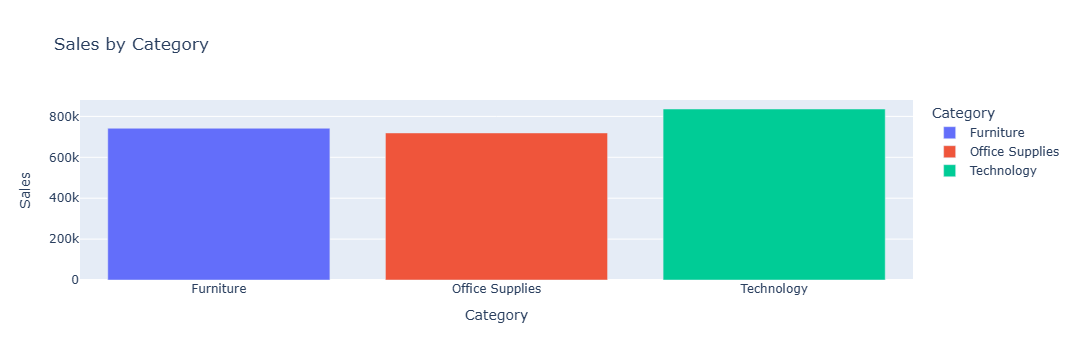

In [9]:
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()
fig = px.bar(cat_sales, x='Category',y='Sales', color='Category',title='Sales by Category')
fig.show()

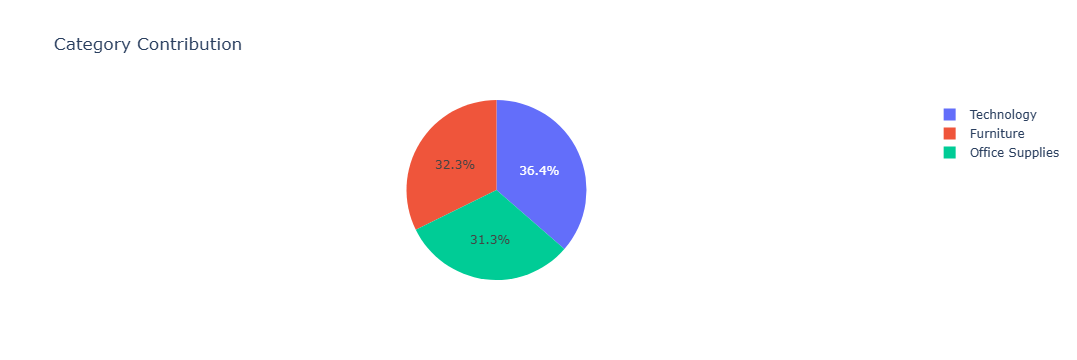

In [12]:
fig = px.pie(cat_sales, names='Category',values='Sales',title='Category Contribution')
fig.show()

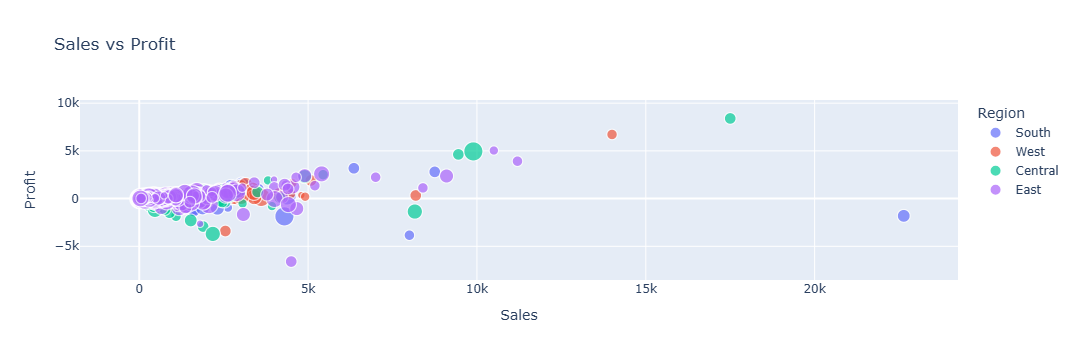

In [11]:
fig = px.scatter(df, x='Sales',y='Profit',color='Region',size='Quantity',title='Sales vs Profit')
fig.show()

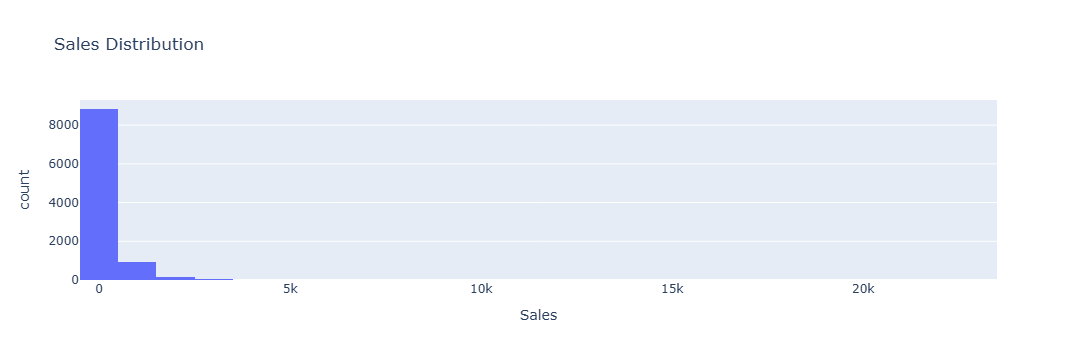

In [13]:
fig = px.histogram(df,x='Sales',nbins=30,title='Sales Distribution')
fig.show()

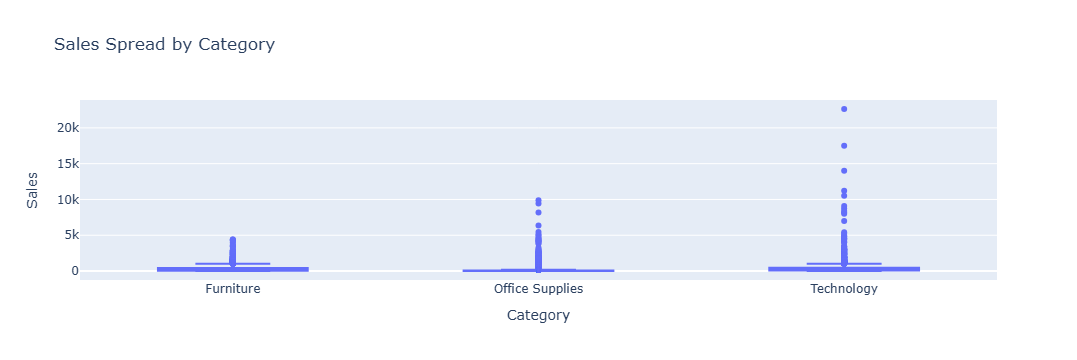

In [14]:
fig = px.box(df,x='Category',y='Sales',title='Sales Spread by Category')
fig.show()

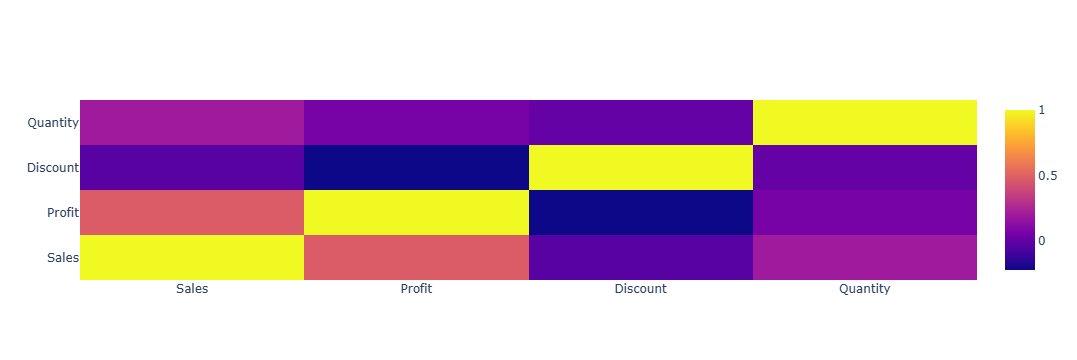

In [16]:
import plotly.graph_objects as go
corr = df[['Sales','Profit','Discount','Quantity']].corr()
fig = go.Figure(data=go.Heatmap(
    z = corr.values, x = corr.columns,y=corr.columns))
fig.show()